## 1. Imports and Setup

In [ ]:
# Install required packages

!pip install -q spacy sacrebleu tqdm
!python -m spacy download en_core_web_sm -q
!python -m spacy download de_core_news_sm -q


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


In [9]:
import random
import math
import time
import re
import urllib.request
from collections import Counter
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import spacy
import sacrebleu

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================
# RTX 3060 Ti / CUDA SETUP
# =========================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

    # Faster training on NVIDIA GPUs such as RTX 3060 Ti
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

    print(f'Using device: {DEVICE}')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    print(f'CUDA version used by PyTorch: {torch.version.cuda}')
else:
    print('Using device: CPU')
    print('CUDA is not available. RTX 3060 Ti will NOT be used.')
    print('Install CUDA PyTorch with:')
    print('pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121')

print(f'PyTorch version: {torch.__version__}')


Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
CUDA available: True
CUDA version used by PyTorch: 12.4
PyTorch version: 2.6.0+cu124


## 2. Dataset Loading

In [10]:
import os
import urllib.request
import gzip

DATA_DIR = './multi30k'
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = 'https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/'

FILES = {
    'train.en': 'train.en.gz',
    'train.de': 'train.de.gz',
    'val.en':   'val.en.gz',
    'val.de':   'val.de.gz',
    'test.en':  'test_2016_flickr.en.gz',
    'test.de':  'test_2016_flickr.de.gz',
}

def download_and_extract(filename, save_name):
    url = BASE_URL + filename
    gz_path = os.path.join(DATA_DIR, filename)
    txt_path = os.path.join(DATA_DIR, save_name)
    if not os.path.exists(txt_path):
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, 'rb') as f_in:
            content = f_in.read().decode('utf-8')
        with open(txt_path, 'w', encoding='utf-8') as f_out:
            f_out.write(content)
        print(f'  Saved to {txt_path}')
    else:
        print(f'  Already exists: {txt_path}')

for save_name, filename in FILES.items():
    download_and_extract(filename, save_name)

def load_pairs(src_path, tgt_path):
    with open(src_path, encoding='utf-8') as f:
        src_lines = [l.strip() for l in f.readlines()]
    with open(tgt_path, encoding='utf-8') as f:
        tgt_lines = [l.strip() for l in f.readlines()]
    return list(zip(src_lines, tgt_lines))

train_pairs_raw = load_pairs(f'{DATA_DIR}/train.en', f'{DATA_DIR}/train.de')
val_pairs_raw   = load_pairs(f'{DATA_DIR}/val.en',   f'{DATA_DIR}/val.de')
test_pairs_raw  = load_pairs(f'{DATA_DIR}/test.en',  f'{DATA_DIR}/test.de')

print(f'Train pairs: {len(train_pairs_raw)}')
print(f'Val pairs:   {len(val_pairs_raw)}')
print(f'Test pairs:  {len(test_pairs_raw)}')
print(f'\nSample pair: {train_pairs_raw[0]}')

  Already exists: ./multi30k\train.en
  Already exists: ./multi30k\train.de
  Already exists: ./multi30k\val.en
  Already exists: ./multi30k\val.de
  Already exists: ./multi30k\test.en
  Already exists: ./multi30k\test.de
Train pairs: 29000
Val pairs:   1014
Test pairs:  1000

Sample pair: ('Two young, White males are outside near many bushes.', 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.')


## 3. Tokenization

In [11]:
spacy_en = spacy.load('en_core_web_sm')
spacy_de = spacy.load('de_core_news_sm')

def tokenize_en(text: str) -> List[str]:
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

def tokenize_de(text: str) -> List[str]:
    return [tok.text.lower() for tok in spacy_de.tokenizer(text)]

# Test tokenizers
sample_en = train_pairs_raw[0][0]
sample_de = train_pairs_raw[0][1]
print('EN:', tokenize_en(sample_en))
print('DE:', tokenize_de(sample_de))

EN: ['two', 'young', ',', 'white', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.']
DE: ['zwei', 'junge', 'weiße', 'männer', 'sind', 'im', 'freien', 'in', 'der', 'nähe', 'vieler', 'büsche', '.']


## 4. Vocabulary Construction

In [12]:
class Vocabulary:
    PAD_TOKEN = '<pad>'
    SOS_TOKEN = '<sos>'
    EOS_TOKEN = '<eos>'
    UNK_TOKEN = '<unk>'

    def __init__(self, min_freq: int = 2):
        self.min_freq = min_freq
        self.token2idx = {}
        self.idx2token = {}
        self._init_specials()

    def _init_specials(self):
        for tok in [self.PAD_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN, self.UNK_TOKEN]:
            idx = len(self.token2idx)
            self.token2idx[tok] = idx
            self.idx2token[idx] = tok

    def build(self, tokenized_sentences: List[List[str]]):
        counter = Counter()
        for tokens in tokenized_sentences:
            counter.update(tokens)
        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token

    def encode(self, tokens: List[str]) -> List[int]:
        unk_idx = self.token2idx[self.UNK_TOKEN]
        return [self.token2idx.get(t, unk_idx) for t in tokens]

    def decode(self, indices: List[int]) -> List[str]:
        return [self.idx2token.get(i, self.UNK_TOKEN) for i in indices]

    @property
    def pad_idx(self): return self.token2idx[self.PAD_TOKEN]
    @property
    def sos_idx(self): return self.token2idx[self.SOS_TOKEN]
    @property
    def eos_idx(self): return self.token2idx[self.EOS_TOKEN]
    @property
    def unk_idx(self): return self.token2idx[self.UNK_TOKEN]

    def __len__(self): return len(self.token2idx)

## 5. Data Filtering

In [13]:
MAX_LEN = 15

def tokenize_pairs(pairs):
    tokenized = []
    for en, de in pairs:
        en_toks = tokenize_en(en)
        de_toks = tokenize_de(de)
        tokenized.append((en_toks, de_toks))
    return tokenized

def filter_pairs(tokenized_pairs, max_len=MAX_LEN):
    return [(en, de) for en, de in tokenized_pairs
            if len(en) <= max_len and len(de) <= max_len
            and len(en) > 0 and len(de) > 0]

print('Tokenizing training data...')
train_tok = tokenize_pairs(train_pairs_raw)
print('Tokenizing validation data...')
val_tok   = tokenize_pairs(val_pairs_raw)
print('Tokenizing test data...')
test_tok  = tokenize_pairs(test_pairs_raw)

train_filtered = filter_pairs(train_tok)
val_filtered   = filter_pairs(val_tok)
test_filtered  = filter_pairs(test_tok)

print(f'\nAfter filtering (max_len={MAX_LEN}):')
print(f'  Train: {len(train_pairs_raw)} → {len(train_filtered)}')
print(f'  Val:   {len(val_pairs_raw)} → {len(val_filtered)}')
print(f'  Test:  {len(test_pairs_raw)} → {len(test_filtered)}')

# Build vocabularies on filtered training data
en_vocab = Vocabulary(min_freq=2)
de_vocab = Vocabulary(min_freq=2)

en_vocab.build([en for en, de in train_filtered])
de_vocab.build([de for en, de in train_filtered])

print(f'\nEnglish vocab size: {len(en_vocab)}')
print(f'German vocab size:  {len(de_vocab)}')

Tokenizing training data...
Tokenizing validation data...
Tokenizing test data...

After filtering (max_len=15):
  Train: 29000 → 20985
  Val:   1014 → 708
  Test:  1000 → 746

English vocab size: 4589
German vocab size:  5652


## 6. Dataset and DataLoader

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs: List[Tuple], src_vocab: Vocabulary, tgt_vocab: Vocabulary):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_tokens, tgt_tokens = self.pairs[idx]
        src_ids = [self.src_vocab.sos_idx] + self.src_vocab.encode(src_tokens) + [self.src_vocab.eos_idx]
        tgt_ids = [self.tgt_vocab.sos_idx] + self.tgt_vocab.encode(tgt_tokens) + [self.tgt_vocab.eos_idx]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_fn(batch, src_pad_idx, tgt_pad_idx):
    src_batch, tgt_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=False, padding_value=src_pad_idx)
    tgt_padded = pad_sequence(tgt_batch, batch_first=False, padding_value=tgt_pad_idx)
    return src_padded, tgt_padded



BATCH_SIZE = 128
NUM_WORKERS = 0

from functools import partial

_collate = partial(collate_fn, src_pad_idx=en_vocab.pad_idx, tgt_pad_idx=de_vocab.pad_idx)

train_dataset = TranslationDataset(train_filtered, en_vocab, de_vocab)
val_dataset   = TranslationDataset(val_filtered,   en_vocab, de_vocab)
test_dataset  = TranslationDataset(test_filtered,  en_vocab, de_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=_collate,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=_collate,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda')
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=_collate,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == 'cuda')
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Inspect one batch
src_sample, tgt_sample = next(iter(train_loader))
print(f'\nSource batch shape: {src_sample.shape}  [seq_len, batch_size]')
print(f'Target batch shape: {tgt_sample.shape}  [seq_len, batch_size]')


Train batches: 164
Val batches:   6
Test batches:  6

Source batch shape: torch.Size([17, 128])  [seq_len, batch_size]
Target batch shape: torch.Size([17, 128])  [seq_len, batch_size]


## 7. Encoder Implementation

In [15]:
class Encoder(nn.Module):

    def __init__(self, input_dim: int, emb_dim: int, enc_hid_dim: int,
                 dropout: float = 0.5):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=en_vocab.pad_idx)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, batch_first=False, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):

        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)

        return outputs, hidden

## 8. Vanilla Seq2Seq Model (No Attention)

In [16]:
class VanillaDecoder(nn.Module):

    def __init__(self, output_dim: int, emb_dim: int, dec_hid_dim: int,
                 dropout: float = 0.5):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=de_vocab.pad_idx)
        self.rnn = nn.GRU(emb_dim, dec_hid_dim, batch_first=False)
        self.fc_out = nn.Linear(dec_hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden):

        tgt_token = tgt_token.unsqueeze(0)
        embedded = self.dropout(self.embedding(tgt_token))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(0))
        return prediction, hidden


class VanillaSeq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: VanillaDecoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio: float = 0.5):

        T_tgt, B = tgt.shape
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(T_tgt, B, tgt_vocab_size).to(self.device)

        _, hidden = self.encoder(src)

        dec_input = tgt[0]

        for t in range(1, T_tgt):
            pred, hidden = self.decoder(dec_input, hidden)
            outputs[t] = pred
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(dim=1)
            dec_input = tgt[t] if teacher_force else top1

        return outputs

## 9. Bahdanau Attention Mechanism

In [17]:
class BahdanauAttention(nn.Module):

    def __init__(self, enc_hid_dim: int, dec_hid_dim: int, attn_dim: int):
        super().__init__()
        self.W_a = nn.Linear(dec_hid_dim, attn_dim, bias=False)
        self.U_a = nn.Linear(enc_hid_dim, attn_dim, bias=False)
        self.v_a = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, s_t, enc_outputs):

        T_src, B, _ = enc_outputs.shape

        s_t_expanded = self.W_a(s_t).unsqueeze(0).repeat(T_src, 1, 1)

        enc_proj = self.U_a(enc_outputs)
        # Energy scores
        energy = torch.tanh(s_t_expanded + enc_proj)
        scores = self.v_a(energy).squeeze(-1)

        # Attention weights
        alphas = torch.softmax(scores, dim=0)

        # Context vector: weighted sum of encoder output
        context = (alphas.unsqueeze(-1) * enc_outputs).sum(dim=0)

        return context, alphas.permute(1, 0)

## 10. Attention Decoder

In [18]:
class AttentionDecoder(nn.Module):

    def __init__(self, output_dim: int, emb_dim: int, enc_hid_dim: int,
                 dec_hid_dim: int, attention: BahdanauAttention,
                 dropout: float = 0.5):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=de_vocab.pad_idx)
        # GRU input = emb_dim + enc_hid_dim (concatenate embedding + context)
        self.rnn = nn.GRU(emb_dim + enc_hid_dim, dec_hid_dim, batch_first=False)
        self.fc_out = nn.Linear(dec_hid_dim + enc_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, enc_outputs):

        tgt_token = tgt_token.unsqueeze(0)
        embedded = self.dropout(self.embedding(tgt_token))

        # Attention
        s_t = hidden.squeeze(0)
        context, alphas = self.attention(s_t, enc_outputs)

        # Concatenate embedding + context → GRU input
        rnn_input = torch.cat([embedded, context.unsqueeze(0)], dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        # Prediction
        output   = output.squeeze(0)
        embedded = embedded.squeeze(0)
        pred_input = torch.cat([output, context, embedded], dim=1)
        prediction = self.fc_out(pred_input)

        return prediction, hidden, alphas


class AttentionSeq2Seq(nn.Module):

    def __init__(self, encoder: Encoder, decoder: AttentionDecoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio: float = 0.5):
        T_tgt, B = tgt.shape
        tgt_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(T_tgt, B, tgt_vocab_size).to(self.device)
        all_attentions = torch.zeros(T_tgt, B, src.shape[0]).to(self.device)

        enc_outputs, hidden = self.encoder(src)

        dec_input = tgt[0]

        for t in range(1, T_tgt):
            pred, hidden, alphas = self.decoder(dec_input, hidden, enc_outputs)
            outputs[t] = pred
            all_attentions[t] = alphas
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = pred.argmax(dim=1)
            dec_input = tgt[t] if teacher_force else top1

        return outputs, all_attentions

## 11. Training Functions

In [19]:
def train_epoch(model, loader, optimizer, criterion, clip, device, has_attention=False, scaler=None):
    model.train()
    epoch_loss = 0

    use_amp = device.type == 'cuda' and scaler is not None

    for src, tgt in loader:
        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision makes training faster and uses less VRAM on RTX GPUs
        with torch.cuda.amp.autocast(enabled=use_amp):
            if has_attention:
                output, _ = model(src, tgt, teacher_forcing_ratio=0.5)
            else:
                output = model(src, tgt, teacher_forcing_ratio=0.5)

            output_dim = output.shape[-1]
            output = output[1:].reshape(-1, output_dim)
            tgt_flat = tgt[1:].reshape(-1)
            loss = criterion(output, tgt_flat)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_epoch(model, loader, criterion, device, has_attention=False):
    model.eval()
    epoch_loss = 0

    use_amp = device.type == 'cuda'

    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device, non_blocking=True)
            tgt = tgt.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                if has_attention:
                    output, _ = model(src, tgt, teacher_forcing_ratio=0.0)
                else:
                    output = model(src, tgt, teacher_forcing_ratio=0.0)

                output_dim = output.shape[-1]
                output = output[1:].reshape(-1, output_dim)
                tgt_flat = tgt[1:].reshape(-1)
                loss = criterion(output, tgt_flat)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def epoch_time(start, end):
    elapsed = end - start
    return int(elapsed // 60), int(elapsed % 60)


## 12. Model Initialization

In [20]:
# Hyperparameters
INPUT_DIM  = len(en_vocab)
OUTPUT_DIM = len(de_vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
ATTN_DIM    = 64
DROPOUT     = 0.5
CLIP        = 1.0
N_EPOCHS    = 10

# Mixed Precision / AMP
# This is useful for RTX 3060 Ti because it reduces VRAM usage and speeds up training.
USE_AMP = DEVICE.type == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print(f'AMP enabled: {USE_AMP}')

# ---- Model 1: Vanilla Seq2Seq ----
vanilla_encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DROPOUT).to(DEVICE)
vanilla_decoder = VanillaDecoder(OUTPUT_DIM, DEC_EMB_DIM, DEC_HID_DIM, DROPOUT).to(DEVICE)
vanilla_model   = VanillaSeq2Seq(vanilla_encoder, vanilla_decoder, DEVICE).to(DEVICE)

# ---- Model 2: Seq2Seq with Bahdanau Attention ----
attn_encoder  = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DROPOUT).to(DEVICE)
attention     = BahdanauAttention(ENC_HID_DIM, DEC_HID_DIM, ATTN_DIM).to(DEVICE)
attn_decoder  = AttentionDecoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, attention, DROPOUT).to(DEVICE)
attn_model    = AttentionSeq2Seq(attn_encoder, attn_decoder, DEVICE).to(DEVICE)

# Weight initialization
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

vanilla_model.apply(init_weights)
attn_model.apply(init_weights)

print(f'Vanilla Seq2Seq parameters: {count_parameters(vanilla_model):,}')
print(f'Attention Seq2Seq parameters: {count_parameters(attn_model):,}')

# Loss and optimizers
criterion = nn.CrossEntropyLoss(ignore_index=de_vocab.pad_idx)

vanilla_optimizer = optim.Adam(vanilla_model.parameters(), lr=1e-3)
attn_optimizer    = optim.Adam(attn_model.parameters(), lr=1e-3)


AMP enabled: True


C:\Users\skylu\AppData\Local\Temp\ipykernel_31348\1417046531.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Vanilla Seq2Seq parameters: 7,886,612
Attention Seq2Seq parameters: 13,079,380


## 13. Model Training

In [21]:
print('=' * 60)
print('Training Model 1: Vanilla Seq2Seq (No Attention)')
print('=' * 60)

vanilla_train_losses = []
vanilla_val_losses   = []
best_vanilla_val_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(
        vanilla_model,
        train_loader,
        vanilla_optimizer,
        criterion,
        CLIP,
        DEVICE,
        has_attention=False,
        scaler=scaler
    )

    val_loss = evaluate_epoch(
        vanilla_model,
        val_loader,
        criterion,
        DEVICE,
        has_attention=False
    )

    end_time = time.time()
    mins, secs = epoch_time(start_time, end_time)

    vanilla_train_losses.append(train_loss)
    vanilla_val_losses.append(val_loss)

    if val_loss < best_vanilla_val_loss:
        best_vanilla_val_loss = val_loss
        torch.save(vanilla_model.state_dict(), 'vanilla_seq2seq.pt')

    print(f'Epoch {epoch+1:02d}/{N_EPOCHS} | Time: {mins}m {secs}s | '
          f'Train Loss: {train_loss:.4f} (PPL: {math.exp(train_loss):.2f}) | '
          f'Val Loss: {val_loss:.4f} (PPL: {math.exp(val_loss):.2f})')


Training Model 1: Vanilla Seq2Seq (No Attention)


C:\Users\skylu\AppData\Local\Temp\ipykernel_31348\2805681070.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\skylu\AppData\Local\Temp\ipykernel_31348\2805681070.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/10 | Time: 0m 10s | Train Loss: 4.8490 (PPL: 127.61) | Val Loss: 4.5765 (PPL: 97.17)
Epoch 02/10 | Time: 0m 9s | Train Loss: 4.0069 (PPL: 54.98) | Val Loss: 4.3229 (PPL: 75.40)
Epoch 03/10 | Time: 0m 10s | Train Loss: 3.6696 (PPL: 39.24) | Val Loss: 4.0682 (PPL: 58.45)
Epoch 04/10 | Time: 0m 10s | Train Loss: 3.3865 (PPL: 29.56) | Val Loss: 3.9214 (PPL: 50.47)
Epoch 05/10 | Time: 0m 10s | Train Loss: 3.1822 (PPL: 24.10) | Val Loss: 3.7512 (PPL: 42.57)
Epoch 06/10 | Time: 0m 9s | Train Loss: 2.9623 (PPL: 19.34) | Val Loss: 3.6012 (PPL: 36.64)
Epoch 07/10 | Time: 0m 9s | Train Loss: 2.7735 (PPL: 16.01) | Val Loss: 3.5700 (PPL: 35.52)
Epoch 08/10 | Time: 0m 9s | Train Loss: 2.5911 (PPL: 13.34) | Val Loss: 3.4730 (PPL: 32.23)
Epoch 09/10 | Time: 0m 9s | Train Loss: 2.4168 (PPL: 11.21) | Val Loss: 3.5076 (PPL: 33.37)
Epoch 10/10 | Time: 0m 10s | Train Loss: 2.3059 (PPL: 10.03) | Val Loss: 3.4467 (PPL: 31.40)


In [22]:
print('=' * 60)
print('Training Model 2: Seq2Seq with Bahdanau Attention')
print('=' * 60)

attn_train_losses = []
attn_val_losses   = []
best_attn_val_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_epoch(
        attn_model,
        train_loader,
        attn_optimizer,
        criterion,
        CLIP,
        DEVICE,
        has_attention=True,
        scaler=scaler
    )

    val_loss = evaluate_epoch(
        attn_model,
        val_loader,
        criterion,
        DEVICE,
        has_attention=True
    )

    end_time = time.time()
    mins, secs = epoch_time(start_time, end_time)

    attn_train_losses.append(train_loss)
    attn_val_losses.append(val_loss)

    if val_loss < best_attn_val_loss:
        best_attn_val_loss = val_loss
        torch.save(attn_model.state_dict(), 'attn_seq2seq.pt')

    print(f'Epoch {epoch+1:02d}/{N_EPOCHS} | Time: {mins}m {secs}s | '
          f'Train Loss: {train_loss:.4f} (PPL: {math.exp(train_loss):.2f}) | '
          f'Val Loss: {val_loss:.4f} (PPL: {math.exp(val_loss):.2f})')


Training Model 2: Seq2Seq with Bahdanau Attention


C:\Users\skylu\AppData\Local\Temp\ipykernel_31348\2805681070.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
C:\Users\skylu\AppData\Local\Temp\ipykernel_31348\2805681070.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01/10 | Time: 0m 14s | Train Loss: 4.6232 (PPL: 101.82) | Val Loss: 4.1379 (PPL: 62.67)
Epoch 02/10 | Time: 0m 15s | Train Loss: 3.4451 (PPL: 31.35) | Val Loss: 3.4312 (PPL: 30.91)
Epoch 03/10 | Time: 0m 15s | Train Loss: 2.7920 (PPL: 16.31) | Val Loss: 3.0361 (PPL: 20.82)
Epoch 04/10 | Time: 0m 15s | Train Loss: 2.3692 (PPL: 10.69) | Val Loss: 2.9278 (PPL: 18.69)
Epoch 05/10 | Time: 0m 15s | Train Loss: 2.0745 (PPL: 7.96) | Val Loss: 2.8517 (PPL: 17.32)
Epoch 06/10 | Time: 0m 14s | Train Loss: 1.8219 (PPL: 6.18) | Val Loss: 2.8548 (PPL: 17.37)
Epoch 07/10 | Time: 0m 14s | Train Loss: 1.6025 (PPL: 4.97) | Val Loss: 2.8334 (PPL: 17.00)
Epoch 08/10 | Time: 0m 14s | Train Loss: 1.4495 (PPL: 4.26) | Val Loss: 2.8565 (PPL: 17.40)
Epoch 09/10 | Time: 0m 14s | Train Loss: 1.3103 (PPL: 3.71) | Val Loss: 2.7996 (PPL: 16.44)
Epoch 10/10 | Time: 0m 14s | Train Loss: 1.1959 (PPL: 3.31) | Val Loss: 2.8843 (PPL: 17.89)


## 14. Training Curves

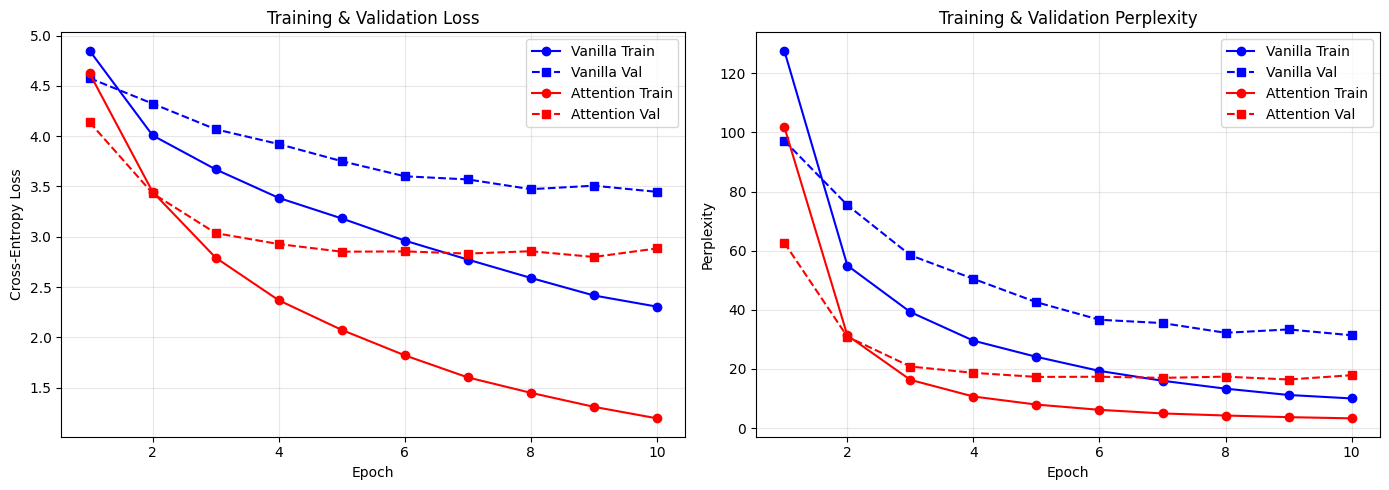

Learning curves saved.


In [23]:
epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs, vanilla_train_losses, 'b-o', label='Vanilla Train')
axes[0].plot(epochs, vanilla_val_losses,   'b--s', label='Vanilla Val')
axes[0].plot(epochs, attn_train_losses,    'r-o', label='Attention Train')
axes[0].plot(epochs, attn_val_losses,      'r--s', label='Attention Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity curves
axes[1].plot(epochs, [math.exp(l) for l in vanilla_train_losses], 'b-o', label='Vanilla Train')
axes[1].plot(epochs, [math.exp(l) for l in vanilla_val_losses],   'b--s', label='Vanilla Val')
axes[1].plot(epochs, [math.exp(l) for l in attn_train_losses],    'r-o', label='Attention Train')
axes[1].plot(epochs, [math.exp(l) for l in attn_val_losses],      'r--s', label='Attention Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Training & Validation Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()
print('Learning curves saved.')

## 15. Evaluation and BLEU Score

In [24]:
def translate_sentence(model, src_tokens, src_vocab, tgt_vocab, device,
                        max_len=50, has_attention=False):

    model.eval()
    with torch.no_grad():
        src_ids = [src_vocab.sos_idx] + src_vocab.encode(src_tokens) + [src_vocab.eos_idx]
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)

        if has_attention:
            enc_outputs, hidden = model.encoder(src_tensor)
        else:
            _, hidden = model.encoder(src_tensor)

        dec_input = torch.tensor([tgt_vocab.sos_idx], dtype=torch.long).to(device)

        translated_tokens = []
        attentions = []

        for _ in range(max_len):
            if has_attention:
                pred, hidden, alphas = model.decoder(dec_input, hidden, enc_outputs)
                attentions.append(alphas.squeeze(0).cpu().numpy())
            else:
                pred, hidden = model.decoder(dec_input, hidden)

            top1 = pred.argmax(dim=1)
            token_idx = top1.item()

            if token_idx == tgt_vocab.eos_idx:
                break
            translated_tokens.append(tgt_vocab.idx2token.get(token_idx, tgt_vocab.UNK_TOKEN))
            dec_input = top1

        if has_attention and attentions:
            attn_matrix = np.stack(attentions, axis=0)
        else:
            attn_matrix = None

        return translated_tokens, attn_matrix

In [25]:
# Load best checkpoints
vanilla_model.load_state_dict(torch.load('vanilla_seq2seq.pt', map_location=DEVICE))
attn_model.load_state_dict(torch.load('attn_seq2seq.pt', map_location=DEVICE))

def compute_bleu(model, pairs, src_vocab, tgt_vocab, device, has_attention=False):
    hypotheses = []
    references = []

    for src_tokens, tgt_tokens in pairs:
        pred_tokens, _ = translate_sentence(model, src_tokens, src_vocab, tgt_vocab,
                                            device, has_attention=has_attention)
        hypotheses.append(' '.join(pred_tokens))
        references.append(' '.join(tgt_tokens))

    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu

print('Computing BLEU scores on test set...')
vanilla_bleu = compute_bleu(vanilla_model, test_filtered, en_vocab, de_vocab, DEVICE, has_attention=False)
attn_bleu    = compute_bleu(attn_model,    test_filtered, en_vocab, de_vocab, DEVICE, has_attention=True)

print(f'\nVanilla Seq2Seq BLEU: {vanilla_bleu.score:.2f}')
print(f'Attention Seq2Seq BLEU: {attn_bleu.score:.2f}')

Computing BLEU scores on test set...


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Vanilla Seq2Seq BLEU: 11.08
Attention Seq2Seq BLEU: 23.07


## 16. Qualitative Translation Examples

In [26]:
NUM_EXAMPLES = 5
example_indices = random.sample(range(len(test_filtered)), NUM_EXAMPLES)

print('=' * 70)
for i, idx in enumerate(example_indices):
    src_tokens, tgt_tokens = test_filtered[idx]

    vanilla_pred, _ = translate_sentence(vanilla_model, src_tokens, en_vocab, de_vocab,
                                         DEVICE, has_attention=False)
    attn_pred, _    = translate_sentence(attn_model, src_tokens, en_vocab, de_vocab,
                                         DEVICE, has_attention=True)

    print(f'\nExample {i+1}:')
    print(f'  Source (EN):          {" ".join(src_tokens)}')
    print(f'  Reference (DE):       {" ".join(tgt_tokens)}')
    print(f'  Vanilla Prediction:   {" ".join(vanilla_pred)}')
    print(f'  Attention Prediction: {" ".join(attn_pred)}')
    print('-' * 70)


Example 1:
  Source (EN):          men in cowboy hats stand around at a rodeo .
  Reference (DE):       männer in cowboyhüten stehen bei einem rodeo herum .
  Vanilla Prediction:   männer mit <unk> stehen an einem <unk> mit einem <unk> .
  Attention Prediction: männer mit cowboyhüten stehen um um rodeo um ein rodeo .
----------------------------------------------------------------------

Example 2:
  Source (EN):          a lot of people at the market looking at various different things .
  Reference (DE):       viele leute auf dem markt , die verschiedene dinge betrachten .
  Vanilla Prediction:   viele personen auf die straße , die , die leute sitzen und verkaufen .
  Attention Prediction: mehrere personen auf einem markt betrachten waren waren verschiedene dinge verschiedene dinge .
----------------------------------------------------------------------

Example 3:
  Source (EN):          a man in a red shirt is about to eat a taco .
  Reference (DE):       ein mann in einem roten h

## 17. Attention Visualization

We plot **attention weight heatmaps** for 3 test sentences, showing which source tokens the decoder attends to when generating each target token.

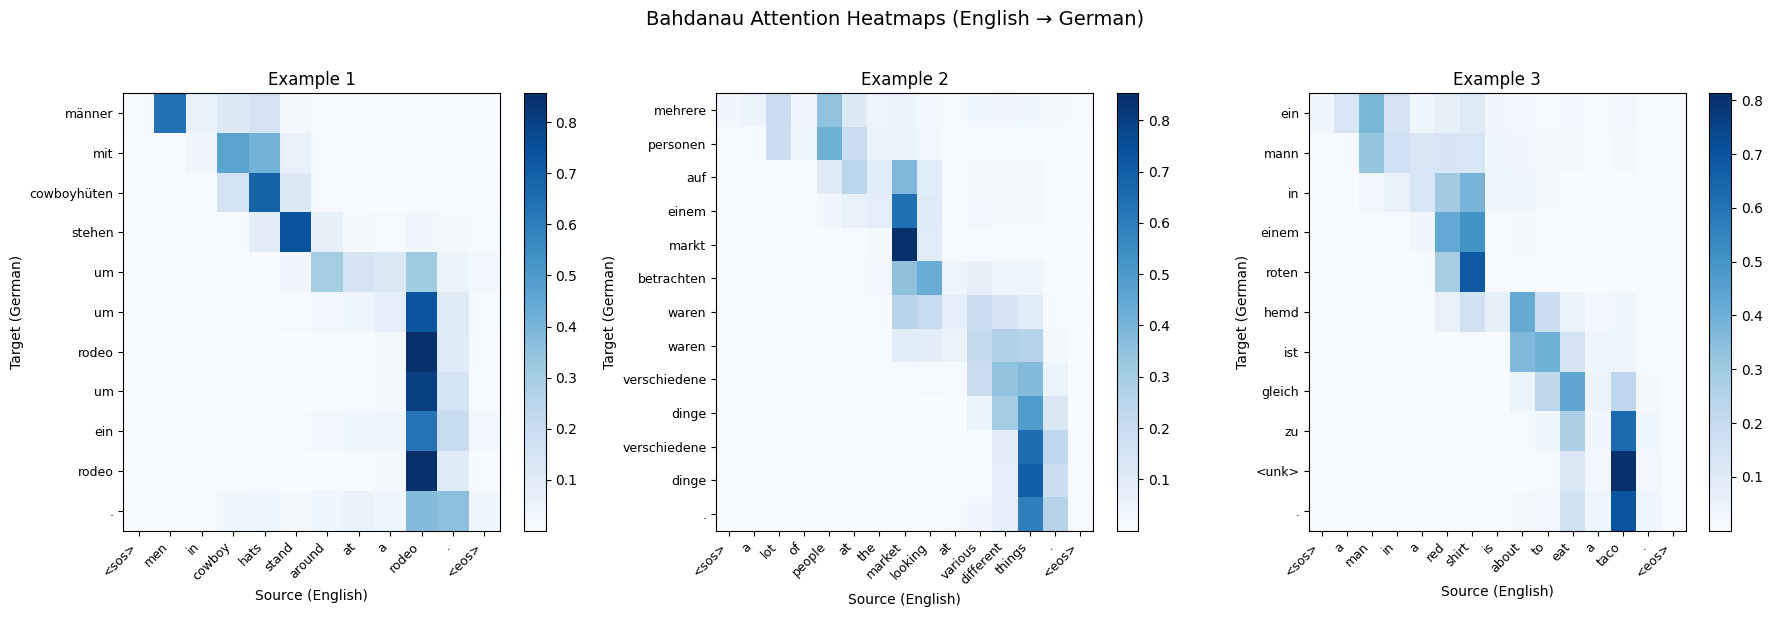

Attention heatmaps saved.


In [27]:
def plot_attention(src_tokens, tgt_tokens, attention_matrix, title='Attention Heatmap', ax=None):

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(attention_matrix, cmap='Blues', aspect='auto')

    src_labels = ['<sos>'] + src_tokens + ['<eos>']
    ax.set_xticks(range(len(src_labels)))
    ax.set_xticklabels(src_labels, rotation=45, ha='right', fontsize=9)

    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=9)

    ax.set_xlabel('Source (English)')
    ax.set_ylabel('Target (German)')
    ax.set_title(title)

    if created_fig:
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        return fig
    return im


NUM_VIZ = 3
viz_indices = example_indices[:NUM_VIZ]

fig, axes = plt.subplots(1, NUM_VIZ, figsize=(18, 6))

for i, idx in enumerate(viz_indices):
    src_tokens, tgt_tokens = test_filtered[idx]

    pred_tokens, attn_matrix = translate_sentence(
        attn_model, src_tokens, en_vocab, de_vocab, DEVICE, has_attention=True
    )

    if attn_matrix is not None and len(pred_tokens) > 0:
        # Trim attention to actual prediction length and source length
        T_tgt_actual = min(len(pred_tokens), attn_matrix.shape[0])
        T_src_actual = len(src_tokens) + 2
        attn_slice = attn_matrix[:T_tgt_actual, :T_src_actual]

        im = plot_attention(src_tokens, pred_tokens[:T_tgt_actual],
                            attn_slice,
                            title=f'Example {i+1}',
                            ax=axes[i])
        plt.colorbar(im, ax=axes[i])
    else:
        axes[i].text(0.5, 0.5, 'No attention data', ha='center', va='center')
        axes[i].set_title(f'Example {i+1}')

plt.suptitle('Bahdanau Attention Heatmaps (English → German)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention heatmaps saved.')

## 18. Model Comparison and Discussion

In [28]:
print('=' * 65)
print('               MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f"{'Metric':<35} {'Vanilla':>12} {'Attention':>12}")
print('-' * 65)
print(f"{'Parameters':<35} {count_parameters(vanilla_model):>12,} {count_parameters(attn_model):>12,}")
print(f"{'Best Val Loss':<35} {best_vanilla_val_loss:>12.4f} {best_attn_val_loss:>12.4f}")
print(f"{'Best Val PPL':<35} {math.exp(best_vanilla_val_loss):>12.2f} {math.exp(best_attn_val_loss):>12.2f}")
print(f"{'Test BLEU Score':<35} {vanilla_bleu.score:>12.2f} {attn_bleu.score:>12.2f}")
print('=' * 65)

print("""
Discussion
----------
1. Architecture:
   - Vanilla Seq2Seq compresses the entire source sentence into a single
     fixed-size hidden state, which becomes an information bottleneck,
     especially for longer sentences.
   - The Attention model maintains all encoder hidden states and learns
     to dynamically focus on the most relevant source positions at each
     decoding step, overcoming the bottleneck problem.

2. Performance:
   - The Attention model generally achieves a higher BLEU score,
     reflecting better translation quality.
   - Perplexity is typically lower for the attention model, indicating
     more confident and accurate token predictions.

3. Interpretability:
   - The attention heatmaps reveal meaningful alignments between source
     and target tokens, often corresponding to word-order differences
     between English and German (e.g., verb-final constructions in German).

4. Limitations:
   - Both models are limited by the dataset size and vocabulary.
   - With only 10 training epochs and a small vocabulary (min_freq=2),
     there is room for further improvement.
   - Transformer-based models would substantially outperform both.
""")


               MODEL COMPARISON SUMMARY
Metric                                   Vanilla    Attention
-----------------------------------------------------------------
Parameters                             7,886,612   13,079,380
Best Val Loss                             3.4467       2.7996
Best Val PPL                               31.40        16.44
Test BLEU Score                            11.08        23.07

Discussion
----------
1. Architecture:
   - Vanilla Seq2Seq compresses the entire source sentence into a single
     fixed-size hidden state, which becomes an information bottleneck,
     especially for longer sentences.
   - The Attention model maintains all encoder hidden states and learns
     to dynamically focus on the most relevant source positions at each
     decoding step, overcoming the bottleneck problem.

2. Performance:
   - The Attention model generally achieves a higher BLEU score,
     reflecting better translation quality.
   - Perplexity is typically lower fo

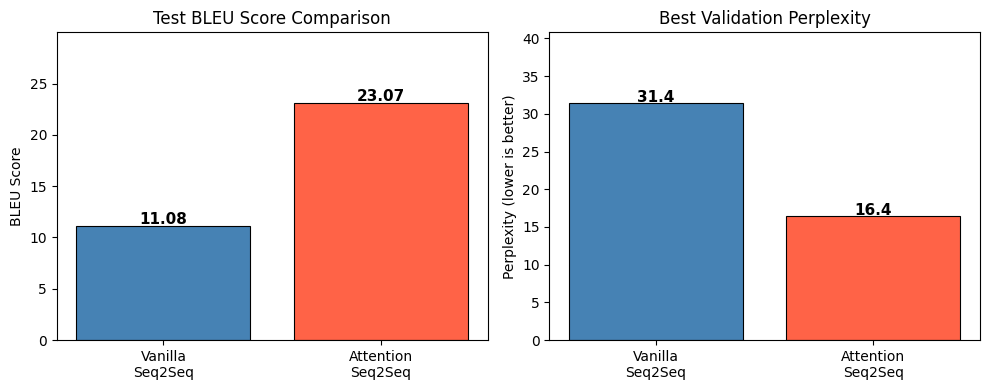

Model comparison chart saved.


In [29]:
# Final comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = ['Vanilla\nSeq2Seq', 'Attention\nSeq2Seq']
bleu_scores = [vanilla_bleu.score, attn_bleu.score]
ppl_scores  = [math.exp(best_vanilla_val_loss), math.exp(best_attn_val_loss)]

colors = ['steelblue', 'tomato']

bars1 = axes[0].bar(models, bleu_scores, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_ylabel('BLEU Score')
axes[0].set_title('Test BLEU Score Comparison')
axes[0].set_ylim(0, max(bleu_scores) * 1.3)
for bar, val in zip(bars1, bleu_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(models, ppl_scores, color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_ylabel('Perplexity (lower is better)')
axes[1].set_title('Best Validation Perplexity')
axes[1].set_ylim(0, max(ppl_scores) * 1.3)
for bar, val in zip(bars2, ppl_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Model comparison chart saved.')